In [22]:
import numpy as np
import timeit
import viscid
import os
from scipy.special import iv

argsdict=viscid.argsdict
from scipy.linalg import eig
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from scipy.signal import find_peaks

import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

import json
colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

start0=timeit.default_timer()

s=5
s2=0.2
admax=5.0
dfreq=10.0
eta=1E-6
argsdict['dim']=2
argsdict['Nx']=3
argsdict['Ny']=3
argsdict['Nt']=3
argsdict['k1x']=np.pi*s
argsdict['k1y']=0
argsdict['k2x']=-np.pi*s/2
argsdict['k2y']=3**0.5*s/2*np.pi
argsdict['h0']=1.0*s2
argsdict['As']=0.75*s2


num1=52
kxs1=np.arange(1,num1+1)/num1*argsdict['k1x']/2
kys1=np.arange(1,num1+1)/num1*0
num2=30
kxs2=argsdict['k1x']/2+np.arange(1,num2+1)/num2*((2*argsdict['k1x'] + argsdict['k2x'])/3 - argsdict['k1x']/2)
kys2=argsdict['k1y']/2+np.arange(1,num2+1)/num2*((2*argsdict['k1y'] + argsdict['k2y'])/3 - argsdict['k1y']/2)
num3=60
kxs3=np.arange(1,num3)/num3*((2*argsdict['k1x'] + argsdict['k2x'])/3)
kys3=np.arange(1,num3)/num3*((2*argsdict['k1y'] + argsdict['k2y'])/3)
ks=np.concatenate([np.transpose([kxs1[-20::4],kys1[-20::4]]),np.transpose([kxs2[::4],kys2[::4]])])

argsdict['rho']=1.0
argsdict['sigma']=20
argsdict['mu']=0.2

Fluid depth in cm

In [23]:
argsdict['h0']

0.2

Substrate amplitude in cm

In [24]:
argsdict['As']

0.15000000000000002

Substrate wavelength in cm

In [25]:
2*np.pi/argsdict['k1x']

0.4

### Dispersion relations and band gap for the inviscid problem

In [26]:
start=timeit.default_timer()

argsdict['As']=0.0
evalssweep1=[]
revecssweep1=[]
levecssweep1=[]
for i in range(num1):
    argsdict['kx']=kxs1[i]
    argsdict['ky']=kys1[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep1=evalssweep1+[evals]
    revecssweep1=revecssweep1+[revecs]
    levecssweep1=levecssweep1+[levecs]
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep2=[]
revecssweep2=[]
levecssweep2=[]
for i in range(num2-1):
    argsdict['kx']=kxs2[i]
    argsdict['ky']=kys2[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep2=evalssweep2+[evals]
    revecssweep2=revecssweep2+[revecs]
    levecssweep2=levecssweep2+[levecs]
    
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep3=[]
revecssweep3=[]
levecssweep3=[]
for i in range(num3-1):
    argsdict['kx']=kxs3[i]
    argsdict['ky']=kys3[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep3=evalssweep3+[evals]
    revecssweep3=revecssweep3+[revecs]
    levecssweep3=levecssweep3+[levecs]

stop=timeit.default_timer()
print(stop-start)

vals1=np.sort(np.real((np.array(evalssweep1))**0.5/(2*np.pi)),axis=1)
vals2=np.sort(np.real((np.array(evalssweep2))**0.5/(2*np.pi)),axis=1)
vals3=np.flip(np.sort(np.real((np.array(evalssweep3))**0.5/(2*np.pi)),axis=1),axis=0)

argsdict['As']=0.75*s2
evalssweep12=[]
revecssweep12=[]
levecssweep12=[]
for i in range(len(kxs1)):
    argsdict['kx']=kxs1[i]
    argsdict['ky']=kys1[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep12=evalssweep12+[evals]
    revecssweep12=revecssweep12+[revecs]
    levecssweep12=levecssweep12+[np.conjugate(levecs)]
    
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep22=[]
revecssweep22=[]
levecssweep22=[]
for i in range(len(kxs2)):
    argsdict['kx']=kxs2[i]
    argsdict['ky']=kys2[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep22=evalssweep22+[evals]
    revecssweep22=revecssweep22+[revecs]
    levecssweep22=levecssweep22+[np.conjugate(levecs)]
    
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep32=[]
revecssweep32=[]
levecssweep32=[]
for i in range(len(kxs3)):
    argsdict['kx']=kxs3[i]
    argsdict['ky']=kys3[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep32=evalssweep32+[evals]
    revecssweep32=revecssweep32+[revecs]
    levecssweep32=levecssweep32+[np.conjugate(levecs)]

stop=timeit.default_timer()
print(stop-start)

vals12=np.sort(np.real((np.array(evalssweep12))**0.5/(2*np.pi)),axis=1)
vals22=np.sort(np.real((np.array(evalssweep22))**0.5/(2*np.pi)),axis=1)
vals32=np.flip(np.sort(np.real((np.array(evalssweep32))**0.5/(2*np.pi)),axis=1),axis=0)


0.06737660383805633
0.03256210871040821
0.07013866724446416
0.3032546490430832
0.13121748808771372
0.2600457901135087


47.34312040782576 40.195297065149234
[40.19529707 40.19529707]
45.52608001811899 39.52455937048163
[37.48932701 39.52455937]


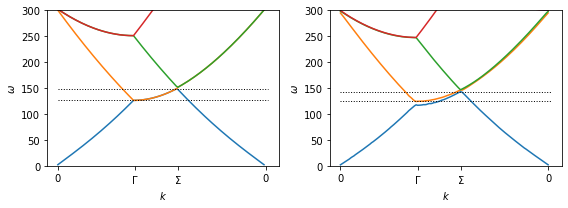

In [27]:
plt.subplots(1,2,figsize=(8,3))

plt.subplot(1,2,1)

plt.ylim(0,300)
plt.plot(np.concatenate([vals1,vals2,vals3])*2*np.pi)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi),np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi),np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals1,vals2,vals3])[:,0]),2*np.min(np.concatenate([vals1,vals2,vals3])[:,1]))
print(vals1[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$\omega$')

plt.subplot(1,2,2)
plt.ylim(0,300)
plt.plot(np.concatenate([vals12,vals22,vals32])*2*np.pi)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi),np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi),np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals12,vals22,vals32])[:,0]),2*np.min(np.concatenate([vals12,vals22,vals32])[:,1]))
print(vals12[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$\omega$')


plt.tight_layout()
plt.savefig('plots/dispersion_experiment.pdf')
plt.show()

47.34312040782576 40.195297065149234
[40.19529707 40.19529707]
45.52608001811899 39.52455937048163
[37.48932701 39.52455937]


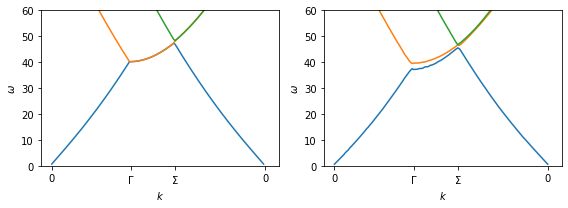

In [30]:
plt.subplots(1,2,figsize=(8,3))

plt.subplot(1,2,1)

plt.ylim(0,60)
plt.plot(np.concatenate([vals1,vals2,vals3])*2)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi),np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi),np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals1,vals2,vals3])[:,0]),2*np.min(np.concatenate([vals1,vals2,vals3])[:,1]))
print(vals1[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$\omega$')

plt.subplot(1,2,2)
plt.ylim(0,60)
plt.plot(np.concatenate([vals12,vals22,vals32])*2)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi),np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi),np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals12,vals22,vals32])[:,0]),2*np.min(np.concatenate([vals12,vals22,vals32])[:,1]))
print(vals12[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$\omega$')


plt.tight_layout()
plt.savefig('plots/dispersion_experiment.pdf')
plt.show()

### Viscid instability boundary

In [8]:
argsdict['ad']=0
argsdict['kx']=ks[0][0]
argsdict['ky']=ks[0][1]
argsdict['verbose']=1
argsdict['dsmin']=1E-4


def mat0(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-argsdict['ad']*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat3(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

def mat(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-ad*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat2(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

Find the starting critical eigenvalues and eigenvectors by continuing the driving amplitude and finding the critical value at fixed frequency and wavenumber

[19.93873072 51.55588217 72.97858585]
n=0 dv=2.128924e-01 dw=6.597496e-01 dl=2.585318e-01
n=1 dv=7.945997e-02 dw=3.063185e-02 dl=2.033010e-02
n=2 dv=1.055348e-01 dw=6.540304e-02 dl=1.716063e-02
n=3 dv=1.044095e-01 dw=1.701569e-01 dl=3.440862e-03
n=4 dv=5.888304e-02 dw=1.244988e-02 dl=5.092119e-03
n=5 dv=5.941061e-02 dw=2.160798e-02 dl=1.888719e-03
n=6 dv=1.032034e-02 dw=3.641536e-03 dl=3.804650e-04
n=7 dv=3.382149e-04 dw=5.388400e-04 dl=1.251655e-05
72.978585845195 (74.09189916848395+20.366324995896715j)
newdir=(-0.000,-0.000,0.316)
m=0 direrr=4.675e-01 res=2.162e+00
m=1 direrr=1.892e-07 res=1.157e-16
m=2 direrr=1.267e-10 res=2.222e-16
m=3 direrr=1.125e-14 res=4.442e-16
m=4 direrr=4.955e-15 res=2.222e-16
m=5 direrr=1.949e-15 res=2.222e-16
m=6 direrr=1.701e-15 res=2.223e-16
m=7 direrr=3.795e-15 res=9.987e-18
step=0 ds=1.000000e-02 ad=0.000000 lambda=232.766566+i63.982697 dir=(-0.000, 0.000, 0.316)
pre dv=1.806e-03 dlambda=0.000e+00 dmu=3.152e-03 ad=0.003162 lr=232.766566 li=63.982697 ms

n=0 dv=3.901e-04 dlambda=4.907e-05 dmu=4.813e-04 ad=0.102460 lr=232.484542 li=63.982697 mstp=1.466e-03
m=0 direrr=2.175e-03 res=1.319e-02
m=1 direrr=1.129e-07 res=7.582e-07
m=2 direrr=1.369e-09 res=4.284e-07
m=3 direrr=1.126e-10 res=4.428e-07
m=4 direrr=1.579e-11 res=4.423e-07
m=5 direrr=2.762e-13 res=4.424e-07
m=6 direrr=1.108e-12 res=4.425e-07
deltadir=-1.094e-03 stp=(-1.427,0.000,0.282) newdir=(-1.558, 0.000, 0.275)
ds=7.594e-02 its=1 ad=0.102460 lambda=232.484542+63.982697i stp=(-1.429,0.000,0.282) mstp=1.466e-03
step=11 ds=7.593750e-02 ad=0.102460 lambda=232.484542+i63.982697 dir=(-1.558, 0.000, 0.275)
pre dv=1.269e-02 dlambda=4.888e-04 dmu=1.860e-02 ad=0.123357 lr=232.366250 li=63.982697 mstp=-2.220e-16
n=0 dv=4.144e-04 dlambda=5.158e-05 dmu=5.414e-04 ad=0.122750 lr=232.353779 li=63.982697 mstp=1.655e-03
m=0 direrr=2.622e-03 res=1.267e-02
m=1 direrr=1.000e-06 res=3.233e-07
m=2 direrr=1.491e-08 res=8.316e-08
m=3 direrr=1.849e-09 res=9.107e-08
m=4 direrr=4.535e-12 res=8.476e-08
m=5

n=0 dv=3.038e-03 dlambda=7.899e-05 dmu=5.734e-03 ad=0.222300 lr=227.445839 li=63.982697 mstp=4.002e-03
m=0 direrr=1.268e-02 res=2.789e-02
m=1 direrr=1.609e-05 res=1.572e-07
m=2 direrr=6.956e-07 res=3.419e-07
m=3 direrr=1.792e-06 res=2.388e-07
m=4 direrr=9.068e-06 res=1.356e-07
deltadir=-6.658e-03 stp=(-2.995,0.000,-0.102) newdir=(-2.858, 0.000, -0.135)
ds=3.844e-01 its=1 ad=0.222300 lambda=227.445839+63.982697i stp=(-3.001,0.000,-0.102) mstp=4.002e-03
step=21 ds=3.844336e-01 ad=0.222300 lambda=227.445839+i63.982697 dir=(-2.858, 0.000, -0.135)
pre dv=4.740e-02 dlambda=4.651e-03 dmu=4.447e-02 ad=0.170255 lr=226.347207 li=63.982697 mstp=0.000e+00
n=0 dv=1.030e-02 dlambda=3.489e-04 dmu=1.576e-02 ad=0.152097 lr=226.429649 li=63.982697 mstp=1.333e-02
n=1 dv=6.439e-04 dlambda=1.040e-05 dmu=2.096e-04 ad=0.152338 lr=226.431968 li=63.982697 mstp=1.320e-02
m=0 direrr=4.069e-02 res=5.089e-02
m=1 direrr=2.571e-05 res=2.672e-06
m=2 direrr=1.584e-07 res=9.246e-07
m=3 direrr=1.280e-07 res=9.385e-07
m=

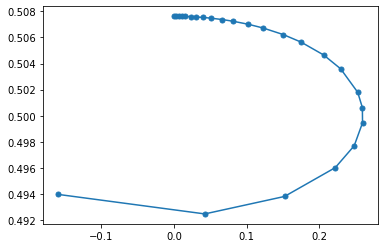

19 0.2607396723706841 (229.25696634200636+63.98269698773128j)
m=0 direrr=5.954e+02 res=1.047e+00
m=1 direrr=2.563e-03 res=8.593e-05
m=2 direrr=3.044e-04 res=7.807e-05
m=3 direrr=4.263e-05 res=2.600e-04
m=4 direrr=1.908e-05 res=2.148e-04
m=5 direrr=1.428e-04 res=2.012e-04
step=0 ds=1.000000e-01 ad=0.260740 lambda=229.256966+i63.982697 dir=(0.000, -3.162, 0.003)
pre dv=2.292e-02 dlambda=1.323e-03 dmu=2.504e-04 ad=0.261055 lr=229.256966 li=63.666514 mstp=-1.110e-16
n=0 dv=2.581e-02 dlambda=3.532e-04 dmu=3.646e-05 ad=0.261101 lr=229.256966 li=63.750884 mstp=1.392e-04
n=1 dv=2.292e-01 dlambda=9.434e-05 dmu=2.102e-02 ad=0.288183 lr=229.256966 li=63.728346 mstp=3.795e-01
n=2 dv=1.634e-01 dlambda=3.394e-04 dmu=2.194e-01 ad=0.650281 lr=229.256966 li=63.732621 mstp=1.143e+01
n=3 dv=1.449e-01 dlambda=2.267e-04 dmu=2.311e-01 ad=1.146358 lr=229.256966 li=63.738518 mstp=2.697e+01
n=4 dv=1.593e-01 dlambda=2.025e-04 dmu=5.093e-03 ad=1.157347 lr=229.256966 li=63.778572 mstp=2.743e+01
n=5 dv=1.327e-01 d

n=1 dv=2.276e-01 dlambda=2.299e-04 dmu=8.692e-02 ad=0.378575 lr=229.256966 li=64.014623 mstp=1.811e+01
n=2 dv=8.869e-02 dlambda=2.791e-04 dmu=1.813e-01 ad=0.683760 lr=229.256966 li=63.957516 mstp=6.699e+01
n=3 dv=2.018e-01 dlambda=1.019e-04 dmu=8.716e-02 ad=0.844534 lr=229.256966 li=63.967584 mstp=9.214e+01
n=4 dv=1.023e-01 dlambda=4.604e-04 dmu=1.777e-01 ad=0.566276 lr=229.256966 li=64.074018 mstp=4.670e+01
n=5 dv=1.018e-01 dlambda=2.538e-04 dmu=6.404e-01 ad=-0.206081 lr=229.256966 li=64.127668 mstp=7.378e+01
n=6 dv=1.681e-01 dlambda=2.281e-04 dmu=1.718e-01 ad=-0.456321 lr=229.256966 li=64.179732 mstp=1.138e+02
n=7 dv=9.478e-02 dlambda=1.977e-04 dmu=3.707e-02 ad=-0.404261 lr=229.256966 li=64.134380 mstp=1.060e+02
n=8 dv=1.731e-01 dlambda=2.101e-04 dmu=2.393e-01 ad=-0.133111 lr=229.256966 li=64.183167 mstp=6.110e+01
n=9 dv=1.066e-01 dlambda=8.163e-05 dmu=2.851e-01 ad=-0.585050 lr=229.256966 li=64.188364 mstp=1.346e+02
Convergence failure!
n=9 ds=1.317e-02 dv=1.066e-01 dlambda=8.163e-05

m=0 direrr=7.202e-05 res=1.775e-03
m=1 direrr=9.443e-05 res=6.360e-06
m=2 direrr=1.864e-04 res=3.903e-06
m=3 direrr=1.671e-04 res=3.266e-06
m=4 direrr=6.579e-05 res=4.336e-06
m=5 direrr=1.717e-05 res=4.193e-06
m=6 direrr=9.596e-06 res=3.678e-06
m=7 direrr=1.002e-05 res=3.852e-06
deltadir=-9.361e-06 stp=(0.000,3.159,0.014) newdir=(0.000, 3.159, 0.015)
ds=1.975e-02 its=1 ad=0.261089 lambda=229.256966+64.219786i stp=(0.000,2.929,0.013) mstp=1.979e-05
step=9 ds=1.975309e-02 ad=0.261089 lambda=229.256966+i64.219786 dir=(0.000, 3.159, 0.015)
pre dv=1.983e-03 dlambda=2.609e-04 dmu=2.376e-04 ad=0.261389 lr=229.256966 li=64.282178 mstp=-2.220e-16
n=0 dv=1.690e-03 dlambda=5.170e-05 dmu=3.043e-05 ad=0.261427 lr=229.256966 li=64.281720 mstp=2.894e-05
m=0 direrr=1.324e-04 res=2.427e-03
m=1 direrr=9.540e-05 res=2.009e-06
m=2 direrr=2.631e-02 res=2.445e-06
m=3 direrr=3.406e-02 res=8.563e-09
m=4 direrr=2.701e-03 res=5.193e-06
m=5 direrr=2.615e-04 res=5.915e-08
m=6 direrr=5.426e-04 res=2.672e-06
deltad

n=0 dv=1.608e-03 dlambda=5.197e-05 dmu=4.999e-04 ad=0.298136 lr=229.256966 li=65.932627 mstp=2.527e-04
m=0 direrr=3.612e-04 res=5.595e-03
m=1 direrr=2.954e-05 res=6.311e-07
m=2 direrr=8.450e-03 res=9.173e-07
m=3 direrr=2.182e-03 res=6.978e-07
m=4 direrr=3.017e-03 res=8.439e-07
deltadir=-1.561e-03 stp=(0.000,2.994,0.102) newdir=(0.000, 2.969, 0.108)
ds=1.000e-01 its=1 ad=0.298136 lambda=229.256966+65.932627i stp=(0.000,2.986,0.102) mstp=2.527e-04
step=20 ds=1.000000e-01 ad=0.298136 lambda=229.256966+i65.932627 dir=(0.000, 2.969, 0.108)
pre dv=1.061e-01 dlambda=1.239e-03 dmu=8.219e-03 ad=0.308894 lr=229.256966 li=66.229530 mstp=0.000e+00
n=0 dv=1.244e-01 dlambda=5.226e-05 dmu=3.401e-04 ad=0.309340 lr=229.256966 li=66.225657 mstp=3.272e-03
n=1 dv=2.047e-02 dlambda=6.165e-05 dmu=2.615e-04 ad=0.309682 lr=229.256966 li=66.234170 mstp=2.790e-03
n=2 dv=1.107e-02 dlambda=5.776e-05 dmu=1.967e-04 ad=0.309425 lr=229.256966 li=66.227667 mstp=3.006e-03
n=3 dv=8.238e-04 dlambda=5.078e-05 dmu=2.665e-0

pre dv=8.146e-03 dlambda=3.717e-03 dmu=3.673e-02 ad=0.580083 lr=229.256966 li=70.959635 mstp=1.110e-16
n=0 dv=3.534e-03 dlambda=5.191e-05 dmu=2.794e-04 ad=0.580524 lr=229.256966 li=70.956161 mstp=1.388e-05
m=0 direrr=8.691e-04 res=1.402e-03
m=1 direrr=1.085e-03 res=3.273e-07
m=2 direrr=1.321e-04 res=1.776e-07
m=3 direrr=5.000e-05 res=2.629e-07
m=4 direrr=2.297e-04 res=2.196e-07
deltadir=-8.583e-05 stp=(0.000,2.645,0.173) newdir=(0.000, 2.629, 0.176)
ds=5.063e-01 its=1 ad=0.580524 lambda=229.256966+70.956161i stp=(0.000,2.644,0.173) mstp=1.388e-05
step=29 ds=5.062500e-01 ad=0.580524 lambda=229.256966+i70.956161 dir=(0.000, 2.629, 0.176)
pre dv=9.777e-02 dlambda=5.514e-03 dmu=5.328e-02 ad=0.669476 lr=229.256966 li=72.287104 mstp=1.110e-16
n=0 dv=1.012e-01 dlambda=1.403e-04 dmu=1.903e-03 ad=0.672660 lr=229.256966 li=72.318780 mstp=6.862e-05
n=1 dv=1.765e-01 dlambda=1.463e-04 dmu=1.375e-03 ad=0.670362 lr=229.256966 li=72.285545 mstp=2.498e-04
n=2 dv=1.395e-01 dlambda=7.395e-05 dmu=5.251e-0

...

n=2 dv=1.633e-01 dlambda=3.522e-04 dmu=2.883e-03 ad=1.917693 lr=229.256966 li=38.814711 mstp=6.861e-05
n=3 dv=1.296e-01 dlambda=2.859e-04 dmu=2.058e-03 ad=1.911700 lr=229.256966 li=38.879936 mstp=5.128e-05
n=4 dv=1.362e-01 dlambda=2.014e-04 dmu=2.637e-03 ad=1.904043 lr=229.256966 li=38.833570 mstp=8.180e-05
n=5 dv=1.834e-01 dlambda=1.477e-04 dmu=9.338e-04 ad=1.901334 lr=229.256966 li=38.811320 mstp=2.052e-04
n=6 dv=1.617e-01 dlambda=3.906e-04 dmu=5.846e-04 ad=1.899639 lr=229.256966 li=38.760501 mstp=4.097e-04
n=7 dv=1.780e-01 dlambda=2.089e-04 dmu=9.056e-04 ad=1.897016 lr=229.256966 li=38.711808 mstp=7.493e-04
n=8 dv=2.292e-01 dlambda=2.484e-04 dmu=1.267e-03 ad=1.893351 lr=229.256966 li=38.761810 mstp=7.507e-04
n=9 dv=1.168e-01 dlambda=1.902e-04 dmu=4.338e-05 ad=1.893476 lr=229.256966 li=38.747412 mstp=8.117e-04
Convergence failure!
n=9 ds=-1.000e+00 dv=1.168e-01 dlambda=1.902e-04 dmu=4.338e-05 stp=(-0.000,2.600,-0.180) mstp=8.117e-04
step=28 ds=-1.000000e+00 ad=1.624093 lambda=229.256

Convergence failure!
n=4 ds=-1.317e-01 dv=2.913e-01 dlambda=6.653e-03 dmu=6.030e-02 stp=(-0.000,-5.380,-1.127) mstp=3.032e+00
step=30 ds=-1.316872e-01 ad=1.854343 lambda=229.256966+i39.635850 dir=(0.000, 2.459, -0.199)
pre dv=4.287e-02 dlambda=1.386e-03 dmu=9.090e-03 ad=1.880526 lr=229.256966 li=39.312061 mstp=-1.110e-16
n=0 dv=7.697e-02 dlambda=2.603e-04 dmu=1.430e-03 ad=1.876414 lr=229.256966 li=39.368254 mstp=2.520e-04
n=1 dv=1.746e-01 dlambda=2.339e-04 dmu=6.235e-03 ad=1.894460 lr=229.256966 li=39.371348 mstp=5.586e-02
n=2 dv=2.873e-01 dlambda=1.973e-04 dmu=3.122e-03 ad=1.885451 lr=229.256966 li=39.398095 mstp=3.447e-02
n=3 dv=1.430e-01 dlambda=2.982e-04 dmu=5.945e-03 ad=1.902707 lr=229.256966 li=39.433317 mstp=1.551e-01
n=4 dv=1.230e-01 dlambda=3.640e-04 dmu=3.902e-04 ad=1.901574 lr=229.256966 li=39.516741 mstp=2.389e-01
n=5 dv=4.864e-02 dlambda=1.473e-04 dmu=7.224e-04 ad=1.903672 lr=229.256966 li=39.509795 mstp=2.471e-01
n=6 dv=2.269e-01 dlambda=5.021e-04 dmu=3.100e-03 ad=1.91270

m=6 direrr=1.495e-05 res=8.198e-06
deltadir=-2.647e-04 stp=(-0.000,2.541,-0.188) newdir=(0.000, 2.518, -0.191)
ds=-3.902e-02 its=3 ad=1.900371 lambda=229.256966+39.027976i stp=(-0.000,2.479,-0.184) mstp=3.985e-05
step=34 ds=-3.901844e-02 ad=1.900371 lambda=229.256966+i39.027976 dir=(0.000, 2.518, -0.191)
pre dv=1.360e-02 dlambda=4.207e-04 dmu=2.566e-03 ad=1.907833 lr=229.256966 li=38.929738 mstp=1.110e-16
n=0 dv=1.803e-02 dlambda=1.418e-04 dmu=1.857e-05 ad=1.907779 lr=229.256966 li=38.929639 mstp=2.624e-04
n=1 dv=9.240e-03 dlambda=1.433e-04 dmu=2.087e-04 ad=1.908386 lr=229.256966 li=38.920640 mstp=4.616e-04
m=0 direrr=8.684e-03 res=1.511e-01
m=1 direrr=7.671e-03 res=1.079e-05
m=2 direrr=2.513e-05 res=6.407e-06
m=3 direrr=5.569e-06 res=5.574e-06
m=4 direrr=2.587e-04 res=3.748e-06
deltadir=-1.391e-04 stp=(-0.000,2.534,-0.189) newdir=(0.000, 2.536, -0.189)
ds=-5.853e-02 its=2 ad=1.908386 lambda=229.256966+38.920640i stp=(-0.000,2.751,-0.205) mstp=4.616e-04
step=35 ds=-5.852766e-02 ad=1.90

n=0 dv=2.629e-02 dlambda=1.660e-04 dmu=5.469e-05 ad=1.932764 lr=229.256966 li=38.595033 mstp=1.811e-02
n=1 dv=7.390e-02 dlambda=4.015e-04 dmu=1.725e-03 ad=1.937832 lr=229.256966 li=38.518229 mstp=2.506e-02
n=2 dv=6.187e-02 dlambda=4.638e-04 dmu=2.325e-03 ad=1.931018 lr=229.256966 li=38.618191 mstp=5.516e-01
n=3 dv=3.201e-02 dlambda=1.968e-04 dmu=5.046e-04 ad=1.932498 lr=229.256966 li=38.597096 mstp=1.509e-02
n=4 dv=4.388e-02 dlambda=2.269e-04 dmu=6.335e-04 ad=1.930641 lr=229.256966 li=38.625620 mstp=1.215e+00
Reject
Convergence failure!
n=4 ds=-5.138e-03 dv=4.388e-02 dlambda=2.269e-04 dmu=6.335e-04 stp=(-0.000,-1.536,0.106) mstp=1.215e+00
step=38 ds=-5.138231e-03 ad=1.931456 lambda=229.256966+i38.613784 dir=(0.000, 2.523, -0.191)
pre dv=2.117e-03 dlambda=5.552e-05 dmu=3.339e-04 ad=1.932435 lr=229.256966 li=38.600822 mstp=-2.220e-16
n=0 dv=1.336e-02 dlambda=2.039e-04 dmu=3.193e-05 ad=1.932341 lr=229.256966 li=38.601166 mstp=9.611e-03
n=1 dv=3.195e-02 dlambda=1.667e-04 dmu=9.282e-04 ad=1

m=0 direrr=2.073e+00 res=2.221e+00
m=1 direrr=2.755e-01 res=8.377e-05
m=2 direrr=3.603e-02 res=1.960e-05
m=3 direrr=6.535e-03 res=5.735e-06
m=4 direrr=1.147e-02 res=5.269e-05
deltadir=-3.748e-01 stp=(-0.000,1.060,-0.217) newdir=(0.000, 2.689, -0.165)
ds=-6.766e-04 its=1 ad=1.932249 lambda=229.256966+38.600613i stp=(-0.000,1.038,-0.212) mstp=2.697e-01
step=44 ds=-6.766395e-04 ad=1.932249 lambda=229.256966+i38.600613 dir=(0.000, 2.689, -0.165)
pre dv=9.861e-04 dlambda=7.794e-06 dmu=3.815e-05 ad=1.932361 lr=229.256966 li=38.598793 mstp=0.000e+00
n=0 dv=6.435e-02 dlambda=1.431e-04 dmu=8.455e-05 ad=1.932609 lr=229.256966 li=38.605427 mstp=6.168e+00
Reject
Convergence failure!
n=0 ds=-4.511e-04 dv=6.435e-02 dlambda=1.431e-04 dmu=8.455e-05 stp=(-0.000,-7.114,-0.532) mstp=6.168e+00
step=44 ds=-4.510930e-04 ad=1.932249 lambda=229.256966+i38.600613 dir=(0.000, 2.689, -0.165)
pre dv=6.574e-04 dlambda=5.196e-06 dmu=2.543e-05 ad=1.932324 lr=229.256966 li=38.599400 mstp=-2.220e-16
n=0 dv=1.917e-02 d

In [34]:
argsdict['kx']=ks[0][0]
argsdict['ky']=ks[0][1]
F,G=viscid.inviscid_mat_undriven(argsdict)
evals,revecs,levecs=eig(F,G,right=True,left=True)
order=np.argsort(np.real(evals))
freq0s=0.9*np.real(evals[order[:3]]**0.5/(2*np.pi/2)) #reduce the frequency a bit relative to inviscid case
print(freq0s)

argsdict['verbose']=3
argsdict['lambdamax']=np.inf
ds=1E-1
dsmax=1E1
argsdict['itmax']=10
argsdict['ds']=ds
argsdict['dsmax']=dsmax
argsdict['dsmin']=1E-4
argsdict['epsl']=1E-2
argsdict['epsu']=1E-2
argsdict['epstp']=np.inf
argsdict['epstp']=1E0
argsdict['thmu']=1E1
argsdict['thl']=1E-1
argsdict['thu']=1E-4

np.random.seed(1)


ads01=[]
ads02=[]
ads03=[]
vs01=[]
vs02=[]
vs03=[]
ws01=[]
ws02=[]
ws03=[]
omegas01=[]
omegas02=[]
omegas03=[]
dirs01=[]

load=True
overwrite=True

start=timeit.default_timer()
for j in range(3):
    if not os.path.exists('data/experiment/%iads01.npy'%(j)) or not load:
        omega=evals[order[j]]**0.5+1j*0
        E,F=viscid.viscid_mat2d(omega,argsdict)

        v=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        w=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        v[2,argsdict['Nt']]=revecs[:,order[j]].reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        w[2,argsdict['Nt']]=levecs[:,order[j]].reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        v=v.ravel()
        w=w.ravel()

        freq0=freq0s[j]
        omega=evals[order[j]]**0.5+1j*0
        argsdict['freq']=freq0
        argsdict['ad']=0

        lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
        kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
        kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
        kappa = (kappax**2+kappay**2)**0.5
        kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
        kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
        S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
        C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

        #right preconditioner
        shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
        shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
        A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
        argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

        argsdict['precondition_axes']=((6,7),(0,1))
        argsdict['precondition_order']=(0,1,2,3,4,5,6,7)


        #starting frequency and driving
        omegas,vs,ws=viscid.rayleigh_mat(omega,v,np.conjugate(w),mat0,argsdict)
        omega0=omegas[-1]
        v0=vs[-1]
        w0=ws[-1]
        print(freq0,omegas[-1]/np.pi)
        argsdict['par']='ad'
        argsdict['pari']=0
        argsdict['parf']=admax
        argsdict['ds']=ds/10
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3, real=1)
        omegas01=omegas01+[omegas]
        vs01=vs01+[vs]
        ws01=ws01+[ws]
        ads01=ads01+[pars]
        dirs01=dirs01+[dirs]
        plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0], marker='o', ms=5)
        plt.show()
        
        ind=np.argmax(pars)
        fomega=interp1d(np.arange(len(omegas)),omegas,kind='cubic')
        fv=interp1d(np.arange(len(omegas)),np.array(vs).T,kind='cubic')
        fw=interp1d(np.arange(len(omegas)),np.array(ws).T,kind='cubic')
        fpar=interp1d(np.arange(len(omegas)),pars,kind='cubic')
        fdir=interp1d(np.arange(len(omegas)),np.array(dirs).T,kind='cubic')

        if ind<len(pars)-3:
            if pars[ind-2]<pars[ind] and pars[ind+2]<pars[ind]:
                find=minimize_scalar(lambda x: -fpar(x),bracket=(ind-1,ind+1)).x
            else:
                find=minimize_scalar(lambda x: fpar(x),bracket=(ind-1,ind+1)).x
        else:
            find=ind
            
        omega0=complex(fomega(find))
        v0=fv(find)
        w0=fw(find)
        dir0=fdir(find)
        s=3*(2*argsdict['Nt']+1)*(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1)
        newdir=np.zeros(dir0.shape)
        newdir[:s]=dir0[s:2*s]
        newdir[s:2*s]=-dir0[:s]
        newdir[2*s]=dir0[2*s+1]
        newdir[2*s+1]=-dir0[2*s]
        newdir[2*s+2]=2*dir0[2*s+2]
        dir0=newdir
        argsdict['ad']=fpar(find)
        print(ind,argsdict['ad'],omega0)
        argsdict['ds']=ds
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0,real=-1)
        omegas02=omegas02+[omegas]
        vs02=vs02+[vs]
        ws02=ws02+[ws]
        ads02=ads02+[pars]
        argsdict['ds']=-ds*10
        argsdict['ad']=fpar(find)
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0,real=-1)
        argsdict['ds']=-argsdict['ds']
        omegas03=omegas03+[omegas]
        vs03=vs03+[vs]
        ws03=ws03+[ws]
        ads03=ads03+[pars]

        if overwrite:
            np.save('data/experiment/%iomegas01.npy'%(j),omegas01[j])
            np.save('data/experiment/%iads01.npy'%(j),ads01[j])
            np.save('data/experiment/%ivs01.npy'%(j),vs01[j])
            np.save('data/experiment/%iws01.npy'%(j),ws01[j])

            np.save('data/experiment/%iomegas02.npy'%(j),omegas02[j])
            np.save('data/experiment/%iads02.npy'%(j),ads02[j])
            np.save('data/experiment/%ivs02.npy'%(j),vs02[j])
            np.save('data/experiment/%iws02.npy'%(j),ws02[j])

            np.save('data/experiment/%iomegas03.npy'%(j),omegas03[j])
            np.save('data/experiment/%iads03.npy'%(j),ads03[j])
            np.save('data/experiment/%ivs03.npy'%(j),vs03[j])
            np.save('data/experiment/%iws03.npy'%(j),ws03[j])
    else:
        omegas01=omegas01+[np.load('data/experiment/%iomegas01.npy'%(j))]
        ads01=ads01+[np.load('data/experiment/%iads01.npy'%(j))]
        vs01=vs01+[np.load('data/experiment/%ivs01.npy'%(j))]
        ws01=ws01+[np.load('data/experiment/%iws01.npy'%(j))]

        omegas02=omegas02+[np.load('data/experiment/%iomegas02.npy'%(j))]
        ads02=ads02+[np.load('data/experiment/%iads02.npy'%(j))]
        vs02=vs02+[np.load('data/experiment/%ivs02.npy'%(j))]
        ws02=ws02+[np.load('data/experiment/%iws02.npy'%(j))]

        omegas03=omegas03+[np.load('data/experiment/%iomegas03.npy'%(j))]
        ads03=ads03+[np.load('data/experiment/%iads03.npy'%(j))]
        vs03=vs03+[np.load('data/experiment/%ivs03.npy'%(j))]
        ws03=ws03+[np.load('data/experiment/%iws03.npy'%(j))]


stop=timeit.default_timer()
print(stop-start)

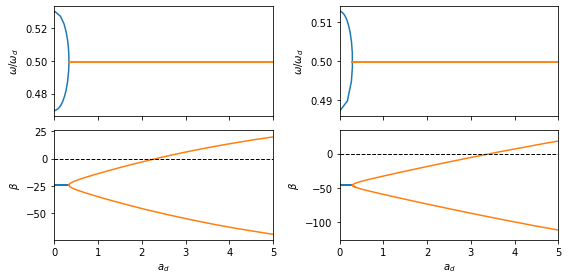

[(2.330157176146874-2.147979141544406e-06j), (3.4485387793542497+1.1700702408961054e-07j)]


In [12]:
ad0s=[]
vn0s=[]
wn0s=[]
argsdict['epsu']=1E-3

for j in range(2):
    freq0=freq0s[j]
    omega=evals[order[j]]**0.5+1j*0
    argsdict['freq']=freq0
    argsdict['ad']=0

    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
    argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)
        
    argsdict['freq']=freq0s[j]
    ind=np.argmin(np.abs(np.imag(omegas03[j])))
    ad0=ads03[j][ind]
    v0=vs03[j][ind]
    w0=ws03[j][ind]
    if np.min(omegas02[j])<0:
        ind=np.argmin(np.abs(np.imag(omegas02[j])))
        ad0=ads02[j][ind]
        v0=vs02[j][ind]
        w0=ws02[j][ind]
    ads,vs,ws=viscid.rayleigh_mat(ad0,v0,w0,mat,argsdict,mat2)
    ad0s=ad0s+[ads[-1]]
    vn0s=vn0s+[vs[-1]]
    wn0s=wn0s+[ws[-1]]
    
plt.subplots(2,2,figsize=(8,4))

for j in range(2):
    plt.subplot(2,2,j+1)
    plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0])
    plt.plot(ads02[j],np.real(omegas02[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.plot(ads03[j],np.real(omegas03[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.xlim(0,admax)

    plt.gca().set_xticks(plt.gca().get_xticks(),['']*len(plt.gca().get_xticks()))
    plt.ylabel(r'$\omega/\omega_d$')

    plt.subplot(2,2,j+3)
    plt.plot(ads01[j],-np.imag(omegas01[j]),c=colors[0])
    plt.plot(ads02[j],-np.imag(omegas02[j]),c=colors[1])
    plt.plot(ads03[j],-np.imag(omegas03[j]),c=colors[1])
    plt.plot([0,admax],[0,0],ls='--',color='black',lw=1)
    plt.ylabel(r'$\beta$')
    plt.xlabel('$a_d$')
    plt.xlim(0,admax)


plt.tight_layout()
plt.show()
print(ad0s)


n=0 dv=2.345567e-02 dw=8.230070e-02 dl=1.934279e-01
n=1 dv=4.296337e-03 dw=7.799348e-03 dl=3.491274e-01
n=2 dv=4.278512e-03 dw=1.844226e-03 dl=1.672930e-01
n=3 dv=1.461744e-03 dw=4.489722e-04 dl=8.098491e-02
n=4 dv=1.928606e-04 dw=3.686661e-04 dl=3.744445e-03
n=0 dv=1.698872e-03 dw=5.837359e-03 dl=4.199685e-02
n=1 dv=2.616580e-04 dw=3.519300e-03 dl=1.396906e-04
n=2 dv=1.410213e-04 dw=2.316102e-03 dl=2.370104e-07
n=3 dv=1.350191e-04 dw=2.121997e-03 dl=3.993349e-07
n=4 dv=2.153487e-04 dw=1.412516e-03 dl=1.697319e-07
n=5 dv=2.490835e-04 dw=5.694371e-04 dl=1.870262e-07
n=0 dv=1.188928e-02 dw=8.638242e-02 dl=4.985422e-01
n=1 dv=6.525992e-02 dw=5.613569e-02 dl=1.654357e-02
n=2 dv=7.204002e-02 dw=7.286172e-02 dl=8.734132e-03
n=3 dv=1.680924e-02 dw=9.423332e-02 dl=5.764042e-03
n=4 dv=4.299543e-02 dw=6.363676e-02 dl=4.379458e-03
n=5 dv=9.219743e-03 dw=2.373612e-02 dl=8.161247e-04
n=6 dv=3.450843e-04 dw=1.630779e-02 dl=9.865630e-05
n=7 dv=7.364658e-04 dw=1.011906e-02 dl=2.574886e-07
n=8 dv=6.309

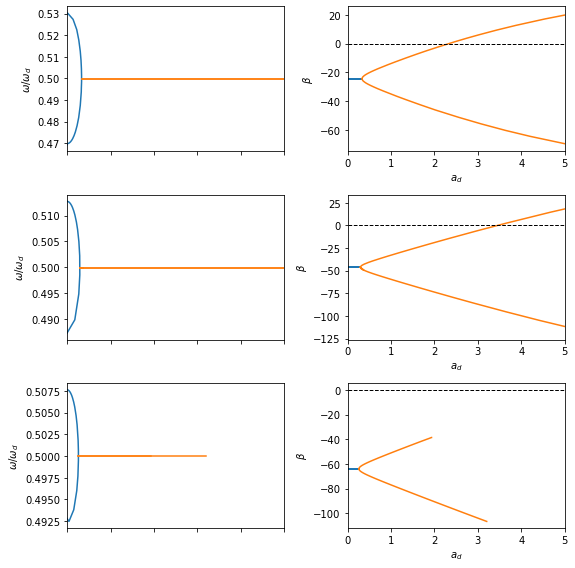

[(2.330157176146874-2.147979141544406e-06j), (3.4485387793542497+1.1700702408961054e-07j), (4.911846853275092+4.6583717172875274e-07j)]


In [36]:
ad0s=[]
vn0s=[]
wn0s=[]
argsdict['epsu']=1E-3

for j in range(3):
    freq0=freq0s[j]
    omega=evals[order[j]]**0.5+1j*0
    argsdict['freq']=freq0
    argsdict['ad']=0

    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
    argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)
        
    argsdict['freq']=freq0s[j]
    ind=np.argmin(np.abs(np.imag(omegas03[j])))
    ad0=ads03[j][ind]
    v0=vs03[j][ind]
    w0=ws03[j][ind]
    if np.min(omegas02[j])<0:
        ind=np.argmin(np.abs(np.imag(omegas02[j])))
        ad0=ads02[j][ind]
        v0=vs02[j][ind]
        w0=ws02[j][ind]
    ads,vs,ws=viscid.rayleigh_mat(ad0,v0,w0,mat,argsdict,mat2)
    ad0s=ad0s+[ads[-1]]
    vn0s=vn0s+[vs[-1]]
    wn0s=wn0s+[ws[-1]]
    
plt.subplots(3,2,figsize=(8,8))

for j in range(3):
    plt.subplot(3,2,2*j+1)
    plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0])
    plt.plot(ads02[j],np.real(omegas02[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.plot(ads03[j],np.real(omegas03[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.xlim(0,admax)

    plt.gca().set_xticks(plt.gca().get_xticks(),['']*len(plt.gca().get_xticks()))
    plt.ylabel(r'$\omega/\omega_d$')

    plt.subplot(3,2,2*j+2)
    plt.plot(ads01[j],-np.imag(omegas01[j]),c=colors[0])
    plt.plot(ads02[j],-np.imag(omegas02[j]),c=colors[1])
    plt.plot(ads03[j],-np.imag(omegas03[j]),c=colors[1])
    plt.plot([0,admax],[0,0],ls='--',color='black',lw=1)
    plt.ylabel(r'$\beta$')
    plt.xlabel('$a_d$')
    plt.xlim(0,admax)


plt.tight_layout()
plt.show()
print(ad0s)


[[4.98425758 0.        ]
 [5.58841001 0.        ]
 [6.19256244 0.        ]
 [6.79671488 0.        ]
 [7.40086731 0.        ]
 [7.85398163 0.15114995]
 [7.85398163 0.75574974]
 [7.85398163 1.36034952]
 [7.85398163 1.96494931]
 [7.85398163 2.5695491 ]
 [7.85398163 3.17414889]
 [7.85398163 3.77874868]
 [7.85398163 4.38334846]]
13
0 19.93873071855976 4.984257575406883 0.0


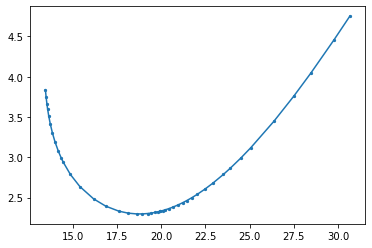

13.452537702295308 30.667237099451896 18.610702174683322 (2.2976327842716686+0.0017081529095360369j)
0.10566497780382633
1 18.610702174683322 5.588410008789536 0.0


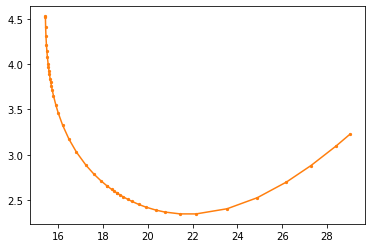

15.418024025098715 29.0208002275484 22.151532337175805 (2.3466240374908733-0.00282512161930202j)
0.1840498079545796
2 22.151532337175805 6.192562442172188 0.0


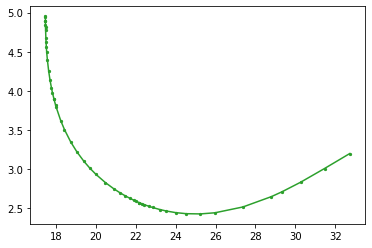

17.45623693191641 32.733598676257024 25.229959748465106 (2.4235507768811226-0.0011944544294794329j)
0.2755029001273215
3 25.229959748465106 6.796714875554841 0.0


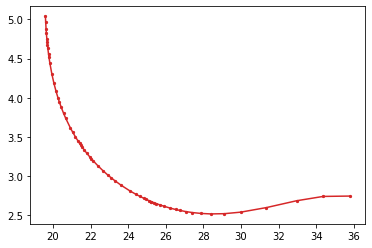

19.59116546888934 35.78549946560659 28.394565841653378 (2.5198684896541046-0.022414699189522214j)
0.37246919702738523
4 28.394565841653378 7.400867308937493 0.0


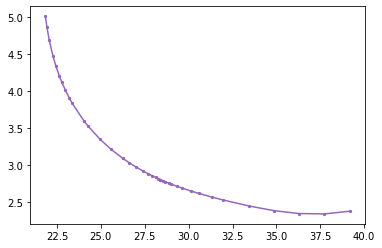

21.839970571902576 39.17706329559873 37.73255214207322 (2.3368718113148836-0.0023689669658224035j)
0.45922570303082466
5 37.73255214207322 7.853981633974483 0.15114994701951814


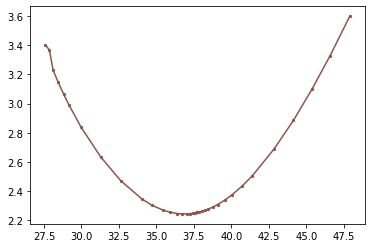

27.595357801830424 47.8999896864605 36.704777255683275 (2.243662385448417+0.0022728123677008367j)
0.567740639206022
6 36.704777255683275 7.853981633974483 0.7557497350975907


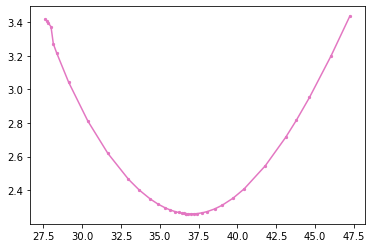

27.636372876376264 47.23144999009067 36.989191196846804 (2.258843288860302-0.0008486097159612605j)
0.6534205442294478
7 36.989191196846804 7.853981633974483 1.3603495231756633


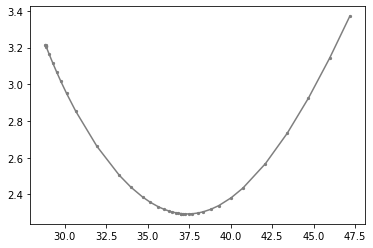

28.842348124028153 47.17474056924746 37.48591974797044 (2.294255871544727+0.0002313393101457036j)
0.7517414819449186
8 37.48591974797044 7.853981633974483 1.964949311253736


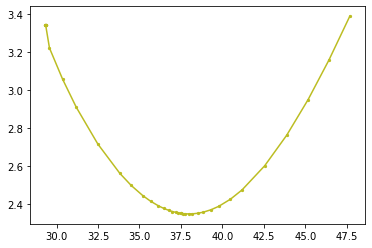

29.33023106961496 47.6849162219819 37.986355946463966 (2.3491033056446655+0.000550216891374419j)
0.8328300071880221
9 37.986355946463966 7.853981633974482 2.5695490993318084


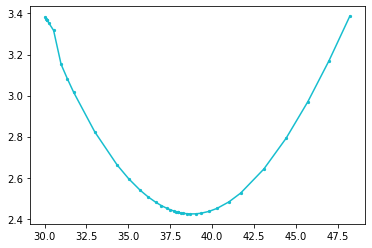

30.048375060783716 48.22189031637864 38.69695811470608 (2.423398600054204-0.000875275298064723j)
0.9293124219402671
10 38.69695811470608 7.853981633974482 3.174148887409881


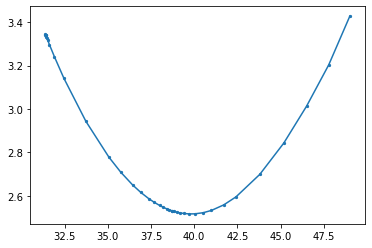

31.390385685375424 49.00274501159239 39.72219331291977 (2.516128615429824+0.0005467744848419896j)
1.022857434116304
11 39.72219331291977 7.853981633974482 3.778748675487954


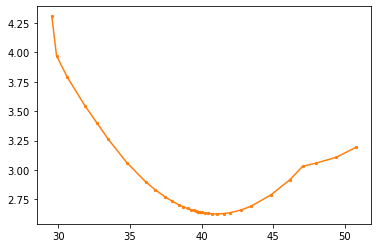

29.534520328692203 50.79974085840797 41.06530600143437 (2.626333036252914-0.00037733565564693715j)
1.1014256682246923
12 41.06530600143437 7.853981633974482 4.383348463566026


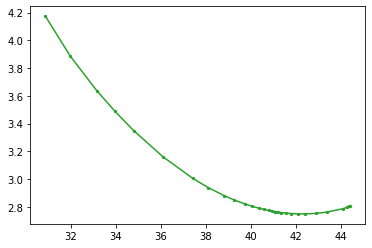

30.86597499145074 44.38877659087161 42.4081173529886 (2.747747093242063+0.0002331171802696304j)
1.184054295066744
0 51.55588216913697 4.984257575406883 0.0


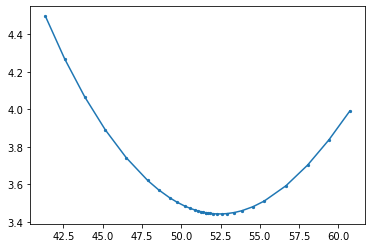

41.36571612406269 60.71976814245646 52.580885088508396 (3.442008262583432+0.00026380629546984694j)
1.2716644341126084
1 52.580885088508396 5.588410008789536 0.0


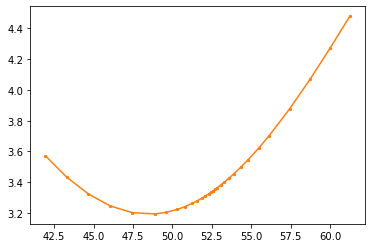

41.948546185767235 61.24260446831894 48.88363574504047 (3.1945725151177764-0.0012294241995238543j)
1.4577784622088075
2 48.88363574504047 6.192562442172188 0.0


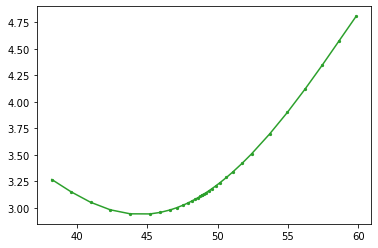

38.22142843374993 59.83658318779489 45.2024614411765 (2.9446672718329263+0.0001845884446869976j)
1.5364815751090646
3 45.2024614411765 6.796714875554841 0.0


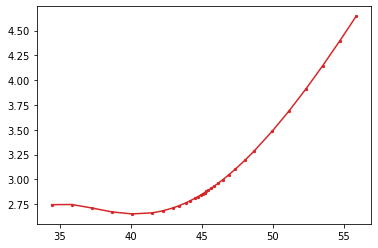

34.45171781560102 55.873909071808676 40.100003165024155 (2.6513954408784595-0.0024070973701911394j)
1.6289056381210685
4 40.100003165024155 7.400867308937493 0.0


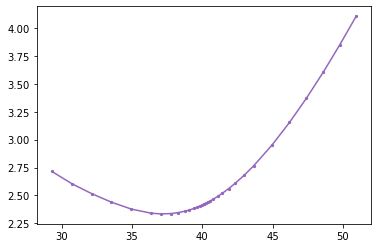

29.293396077288403 50.9512244544318 37.08500202934544 (2.3342632129783323+0.006583003321710451j)
1.7068414348177612
5 37.08500202934544 7.853981633974483 0.15114994701951814


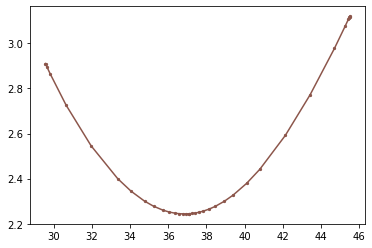

29.57522825313604 45.498939036779994 36.935932027362654 (2.243441456737992+0.000872102550304948j)
1.8004878498613834
6 36.935932027362654 7.853981633974483 0.7557497350975907


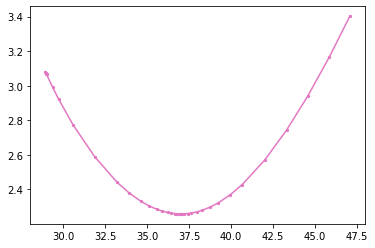

28.951325318168436 47.06875681244913 36.935932027362654 (2.2587718616409673-2.608152301536409e-06j)
1.8849335792474449
7 36.935932027362654 7.853981633974483 1.3603495231756633


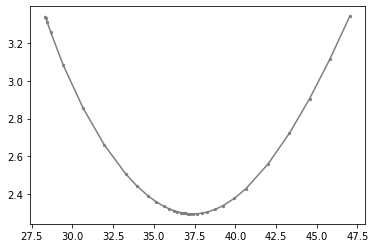

28.34408062014506 47.030425747399455 37.43179028168419 (2.2941546709667278+0.0003603373571359231j)
1.9651071960106492
8 37.43179028168419 7.853981633974483 1.964949311253736


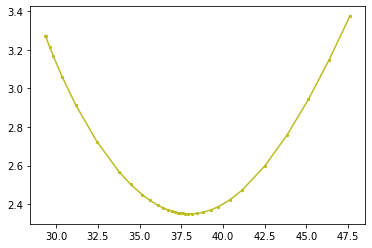

29.35244408004507 47.602726617142736 37.92873204737373 (2.349155035420973+0.00029972117246654254j)
2.0518288440071046
9 37.92873204737373 7.853981633974482 2.5695490993318084


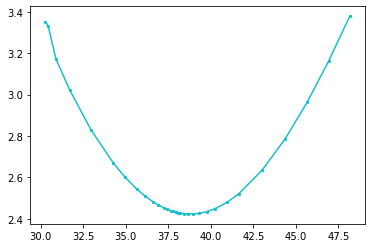

30.26475399732834 48.17706537837095 38.95515299080087 (2.4235185750559594+6.090097620952801e-05j)
2.150136162992567
10 38.95515299080087 7.853981633974482 3.174148887409881


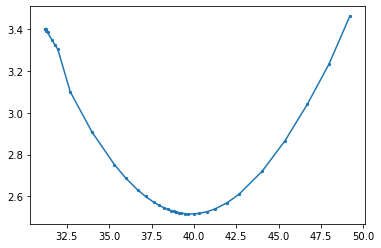

31.23551746259765 49.20734991468387 39.980526059034034 (2.516279580133456+0.0009085074139443231j)
2.2442159890197217
11 39.980526059034034 7.853981633974482 3.778748675487954


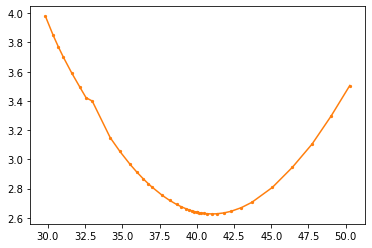

29.83536191942424 50.27192938139853 41.00567517618156 (2.626336392179076-0.00106669489947898j)
2.3461677259765565
12 41.00567517618156 7.853981633974482 4.383348463566026


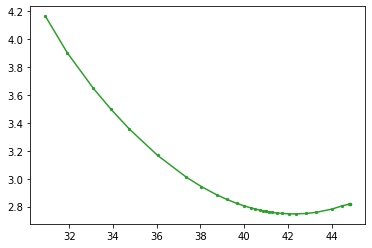

30.905348731461626 44.830565109307486 42.34836213394682 (2.7476598752174244-0.0011306226506520392j)
2.453662997111678


In [21]:
start=timeit.default_timer()
adssweep=[]
freqsweep=[]
vssweep=[]
wssweep=[]
dirsweep=[]
dssweep=[]
argsdict['verbose']=1
argsdict['lambdamax']=admax
maxfreq=60

ds=1E0
ds0=1E-1
argsdict['dsmax']=ds
argsdict['ds']=ds0
argsdict['dsmin']=1E-8

argsdict['epsu']=1E-2
argsdict['epsl']=1E-2
argsdict['dmu_fd']=1E-4
argsdict['epstp']=5E-1
argsdict['epdir']=1E-3
argsdict['thmu']=5E-1
argsdict['thl']=5E0
argsdict['thu']=1E-4

argsdict['itmax']=10
argsdict['Nsteps']=5000
np.random.seed(1)

print(ks)
print(len(ks))
load=True
overwrite=True

l=0

for j in range(2):
    ad0=ad0s[j]
    vs0=vn0s[j]
    ws0=wn0s[j]
    freq0=freq0s[j]
    
    argsdict['freq']=freq0
    argsdict['kx']=ks[0][0]
    argsdict['ky']=ks[0][1]
    
    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
    argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

    for i in range(len(ks)):
        kx=ks[i][0]
        ky=ks[i][1]
        print(i,freq0,kx,ky)
        if not os.path.exists('data/experiment/%iads.npy'%(l)) or not load:
            argsdict['freq']=freq0
            if(argsdict['kx']!=kx):
                argsdict['par']='kx'
                argsdict['pari']=np.min([kx,argsdict['kx']])
                argsdict['parf']=np.max([kx,argsdict['kx']])

                argsdict['ds']=np.sign(kx-argsdict['kx'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['kx']=kx
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]
            if(argsdict['ky']!=ky):
                argsdict['par']='ky'
                argsdict['pari']=np.min([ky,argsdict['ky']])
                argsdict['parf']=np.max([ky,argsdict['ky']])

                argsdict['ds']=np.sign(ky-argsdict['ky'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['ky']=ky
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]

            lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
            kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
            kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
            kappa = (kappax**2+kappay**2)**0.5
            kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
            kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
            S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
            C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

            #right preconditioner
            shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
            shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
            A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
            argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

            argsdict['precondition_axes']=((6,7),(0,1))
            argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

            argsdict['freq']=freq0
            argsdict['par']='freq'
            argsdict['pari']=freq0-dfreq
            argsdict['parf']=np.min([freq0+dfreq,maxfreq])

            argsdict['ds']=ds0
            np.random.seed(l)
            ads2,vs2,ws2,pars2,dirs2,dss2=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2, real=True)
            argsdict['freq']=freq0        
            argsdict['ds']=-ds0
            np.random.seed(l)
            ads3,vs3,ws3,pars3,dirs3,dss3=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2, real=True) 
            

            freqsweep=freqsweep+[np.flip(pars3).tolist()+pars2]
            adssweep=adssweep+[np.flip(ads3).tolist()+ads2]
            vssweep=vssweep+[np.flip(vs3,axis=0).tolist()+vs2]
            wssweep=wssweep+[np.flip(ws3,axis=0).tolist()+ws2]
            dirsweep=dirsweep+[np.flip(dirs3,axis=0).tolist()+dirs2]
            dssweep=dssweep+[np.flip(dss3,axis=0).tolist()+dss2]
            if overwrite:
                np.save('data/experiment/%iads.npy'%(l),adssweep[l])
                np.save('data/experiment/%ivs.npy'%(l),vssweep[l])
                np.save('data/experiment/%iws.npy'%(l),wssweep[l])
                np.save('data/experiment/%ifreqs.npy'%(l),freqsweep[l])
                np.save('data/experiment/%idirs.npy'%(l),dirsweep[l])
                np.save('data/experiment/%idss.npy'%(l),dssweep[l])

        else:
            adssweep=adssweep+[np.load('data/experiment/%iads.npy'%(l))]
            vssweep=vssweep+[np.load('data/experiment/%ivs.npy'%(l))]
            wssweep=wssweep+[np.load('data/experiment/%iws.npy'%(l))]
            freqsweep=freqsweep+[np.load('data/experiment/%ifreqs.npy'%(l))]
            dirsweep=dirsweep+[np.load('data/experiment/%idirs.npy'%(l))]
            dssweep=dssweep+[np.load('data/experiment/%idss.npy'%(l))]
            argsdict['kx']=kx
            argsdict['ky']=ky

        plt.plot(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[i%len(colors)])
        plt.scatter(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[i%len(colors)],s=5)
        plt.show() 
            
        peaks,pprop=find_peaks(-np.abs(adssweep[-1]))
        ind=peaks[np.argmin(np.abs(np.array(freqsweep[-1])[peaks]-freq0))]
        ad0=adssweep[-1][ind]
        vs0=np.array(vssweep[-1][ind])
        ws0=np.array(wssweep[-1][ind])
        freq0=freqsweep[-1][ind]
        print(freqsweep[-1][0],freqsweep[-1][-1],freq0,ad0)
        
        l=l+1

        stop=timeit.default_timer()
        print(stop-start)

In [58]:
adssweep=[np.load('data/experiment/%iads.npy'%(i)) for i in range(2*len(ks))]
vssweep=[np.load('data/experiment/%ivs.npy'%(i)) for i in range(2*len(ks))]
wssweep=[np.load('data/experiment/%iws.npy'%(i)) for i in range(2*len(ks))]
freqsweep=[np.load('data/experiment/%ifreqs.npy'%(i)) for i in range(2*len(ks))]
dirsweep=[np.load('data/experiment/%idirs.npy'%(i)) for i in range(2*len(ks))]
dssweep=[np.load('data/experiment/%idss.npy'%(i)) for i in range(2*len(ks))]

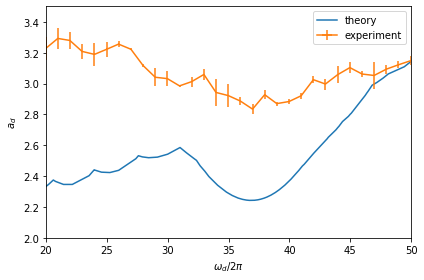

In [20]:
plotfreqs=20+(50-20)*np.arange(1000)/1000
acs=[]
for i in range(2*len(ks)):
    f=interp1d(np.array(freqsweep[i]),np.real(adssweep[i]))
    inds=np.intersect1d(np.where(plotfreqs<np.max(freqsweep[i]))[0],np.where(plotfreqs>np.min(freqsweep[i]))[0])
    ac=np.ones(len(plotfreqs))*np.inf
    ac[inds]=f(plotfreqs[inds])
    acs=acs+[ac]
plt.plot(plotfreqs,np.min(np.array(acs),axis=0),label='theory')
plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
plt.ylim(0,20.0)
plt.tight_layout()
filebases=['data/experiment/new_20_50/new_20_50','data/experiment/new_20_50_2/new_20_50_2','data/experiment/new_20_50_3/new_20_50_3']
dats=[]
for filebase in filebases:
    dat=np.loadtxt('%s.txt'%(filebase))
    order=np.argsort(dat[:,2])
    dats=dats+[dat[order]]
x,y=np.mean(np.array(dats)[:,:,[2,1]],axis=0).T
xerr,yerr=np.std(np.array(dats)[:,:,[2,1]],axis=0).T
plt.errorbar(x,y,xerr=xerr,yerr=yerr,label='experiment')
plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
plt.xlim(20,50)
plt.ylim(2,3.5)
plt.tight_layout()
plt.legend()
plt.savefig('experiment.pdf')
plt.show()